In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")
from scipy import stats

from lib.utils.annotation import annotation_text
from lib.utils.annotation import barplot_annotate_brackets

In [2]:
# Plot color
cols1 = sns.color_palette("Oranges", 2)
cols2 = sns.color_palette("Blues", 2)
cols3 =sns.color_palette("Greys", 2)

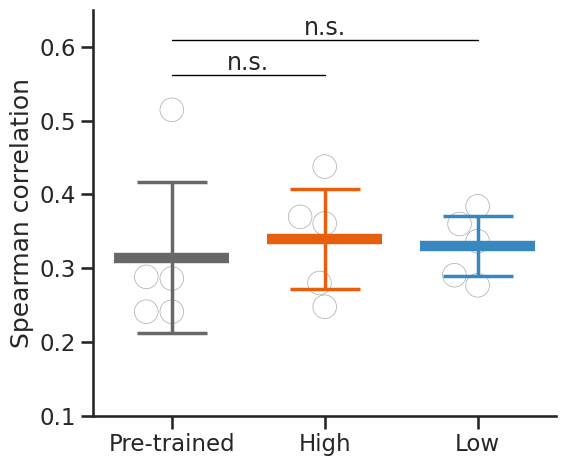

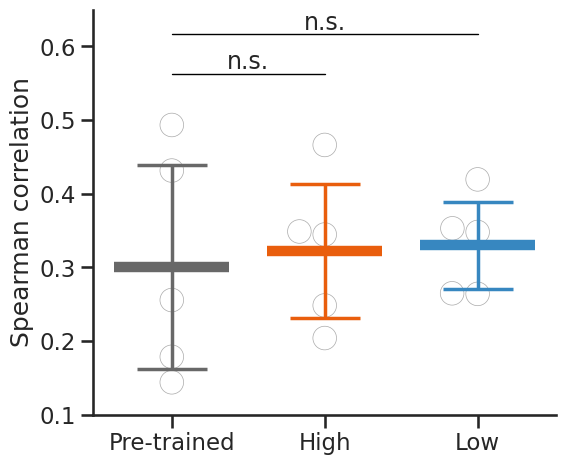

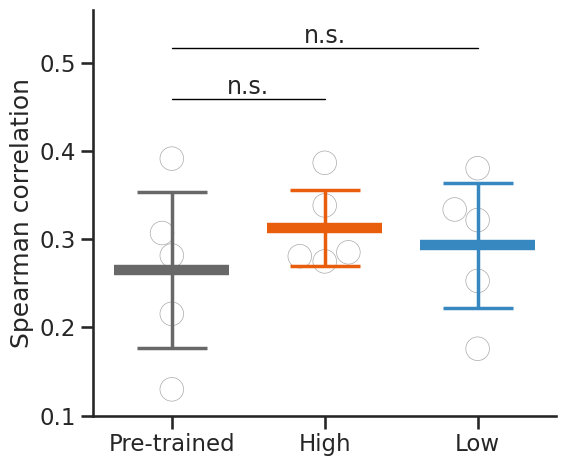

In [3]:
# Finetuned ESM2-8M, 150M, and 650M
scores = pd.read_csv("./tables/scores_ridge.csv")

for model_size in [8, 150, 650]:

    scores_ext = scores[scores.plm_size == model_size]
    scores_ext.insert(1, "x", scores_ext.db_size.apply(lambda x: 0 if x == "-" else 1 if x == "high" else 2))
    
    # Plot
    x = range(1, 4, 1)
    vals = [rows.spearmanr.tolist() for _, rows in scores_ext.groupby("db_size")]

    if model_size == 8:
        ymax = 0.65
        dh1 = 0.4
        dh2 = 0.47
    if model_size == 150:
        ymax = 0.65
        dh1 = 0.28
        dh2 = 0.35
    if model_size == 650:
        ymax = 0.56
        dh1 = 0.33
        dh2 = 0.4
    
    cols1 = sns.color_palette("Greys", 2)
    cols2 = sns.color_palette("Oranges", 2)
    cols3 = sns.color_palette("Blues", 2)
    colors = [cols1[1], cols2[1], cols3[1]]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.swarmplot(
        ax=ax,
        data=scores_ext,
        x="x",
        y="spearmanr",
        hue="db_size",
        s=17,
        palette=["none", "none", "none"],
        edgecolor="darkgray",
        linewidth=0.5,
        zorder=1,
        legend=None
    )
    for pos, val, color in zip(range(3), vals, colors):
        sns.boxplot(
            showmeans=True,
            ax=ax,
            meanline=True,
            meanprops={'color': color, 'ls': '-', 'lw': 7.5},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            x=pos,
            y=val,
            showfliers=False,
            showbox=False,
            showcaps=False,
            width=0.75,
            zorder=2
        )
        ax.errorbar(pos, np.mean(val), np.std(val), lw=2.5, capthick=2.5, capsize=25, color=color, zorder=2)
        
    
    # Compute and visualize p-value
    v1 = scores_ext[scores_ext.db_size == "-"].spearmanr.tolist()
    v2 = scores_ext[scores_ext.db_size == "high"].spearmanr.tolist()
    v3 = scores_ext[scores_ext.db_size == "low"].spearmanr.tolist()
    p_values = stats.dunnett(v2, v3, control=v1).pvalue
    
    barplot_annotate_brackets(
        0,
        1,
        annotation_text(p_values[0]),
        range(3),
        scores_ext.groupby("db_size").spearmanr.mean().tolist(),
        yerr=scores_ext.groupby("db_size").spearmanr.std().tolist(),
        dh=dh1,
        barh=0.0,
        linewidth=1,
        fs=17.0
    )
    barplot_annotate_brackets(
        0,
        2,
        annotation_text(p_values[1]),
        range(3),
        scores_ext.groupby("db_size").spearmanr.mean().tolist(),
        yerr=scores_ext.groupby("db_size").spearmanr.std().tolist(),
        dh=dh2,
        barh=0.0,
        linewidth=1,
        fs=17.0
    )
    ax.set_ylim(0.1, ymax)
    ax.set_xlabel("")
    ax.set_ylabel("Spearman correlation")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Pre-trained", "High", "Low"])
    ax.set_yticks(np.arange(0.1, ymax, 0.1))
    sns.despine()
    fig.tight_layout()
    fig.savefig(f"./figures/spearmanr_ridge_{model_size}m.svg")